# 01 · Multi-Layer Perceptron for XOR (step activation only)
NumPy for the model · matplotlib for graphs · Runs on Google Colab

XOR = **AND( OR(x₁, x₂), NAND(x₁, x₂) )**

## Data

In [1]:
import numpy as np

X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])
y_or   = np.array([0, 1, 1, 1])
y_nand = np.array([1, 1, 1, 0])
y_xor  = np.array([0, 1, 1, 0])

print(" x1  x2 | OR  NAND | AND(OR, NAND) | XOR")
for x, a, b, c in zip(X, y_or, y_nand, y_xor):
    print(f"  {x[0]}   {x[1]} |  {a}    {b}   |       {a & b}       |  {c}")

rng = np.random.default_rng(42)

 x1  x2 | OR  NAND | AND(OR, NAND) | XOR
  0   0 |  0    1   |       0       |  0
  0   1 |  1    1   |       1       |  1
  1   0 |  1    1   |       1       |  1
  1   1 |  1    0   |       0       |  0


## Perceptron functions (same as before, threshold as $w_0$ on input $x_0 = -1$)

| Function | Formula |
|---|---|
| `step(s)` | $1$ if $s \ge 0$ else $0$ |
| `forward_pass(x, w)` | $s = x \cdot w$, then $\hat{y} = \text{step}(s)$ |
| `compute_error(y, y_hat)` | $y - \hat{y}$ |
| `backward_pass(w, x, error, lr)` | $w + \eta \cdot \text{error} \cdot x$ |

In [2]:
def add_x0(X):
    return np.hstack([-np.ones((len(X), 1), dtype=int), X])       # x0 = -1, so w0 is the threshold

def step(s):
    return 1 if s >= 0 else 0

def forward_pass(x, w):
    s = np.round(x @ w, 10) + 0.0             # weighted sum (rounding removes float noise and -0)
    return step(s), s

def compute_error(y, y_hat):
    return y - y_hat

def backward_pass(w, x, error, lr):
    return np.round(w + lr * error * x, 10) + 0.0


def train(X, y, w, lr, epochs):
    history = [w]
    for epoch in range(1, epochs + 1):
        print(f"--- Epoch {epoch} ---")
        mistakes = 0
        for x, target in zip(X, y):
            y_hat, s = forward_pass(x, w)
            error = compute_error(target, y_hat)
            new_w = backward_pass(w, x, error, lr)

            calc = " + ".join(f"{xi:g}×{wi:g}" for xi, wi in zip(x, w))
            print(f"x={x} | s = {calc} = {s:g} ≥ 0? -> {y_hat} | error = {target}-{y_hat} = {error:>2} | w = {new_w}")

            mistakes += int(error != 0)
            w = new_w
        print(f"mistakes: {mistakes}\n")
        history.append(w)
        if mistakes == 0:
            print(f"Learned in {epoch} epochs: w = {w}")
            return w, epoch, history
    print(f"Not learned in {epochs} epochs: w = {w}")
    return w, None, history

## MLP functions: hidden layer ➜ output layer

In [3]:
def hidden_layer(X, W_hidden):
    # one column per hidden neuron: h_j = step(x · w_j)
    return np.array([[forward_pass(x, w)[0] for w in W_hidden] for x in add_x0(X)])

def mlp_forward(X, W_hidden, w_out):
    H = hidden_layer(X, W_hidden)
    y_hat = np.array([forward_pass(h, w_out)[0] for h in add_x0(H)])
    return y_hat, H

def show_mlp(X, y, W_hidden, w_out):
    y_hat, H = mlp_forward(X, W_hidden, w_out)
    for x, h, out, target in zip(X, H, y_hat, y):
        hs = " ".join(f"h{j + 1}={hj}" for j, hj in enumerate(h))
        print(f"x={x} -> hidden [{hs}] -> output {out} | target {target} {'✓' if out == target else '✗'}")
    print(f"\nAccuracy: {(y_hat == y).sum()}/{len(y)}")

## Plot helpers

In [4]:
import io, contextlib, warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", message="No contour levels")

grid = np.linspace(-0.5, 1.5, 300)
G1, G2 = np.meshgrid(grid, grid)
P0 = np.c_[-np.ones(G1.size), G1.ravel(), G2.ravel()]           # every grid point with x0 = -1

def train_quiet(X, y, w, lr, epochs):
    with contextlib.redirect_stdout(io.StringIO()):
        return train(X, y, w, lr, epochs)

def draw_line(ax, w, color="k", style="-", label=None):
    # boundary of one neuron: w1*x1 + w2*x2 = w0
    S = w[1] * G1 + w[2] * G2 - w[0]
    ax.contour(G1, G2, S, levels=[0], colors=[color], linestyles=style, linewidths=2)
    if label:
        ax.plot([], [], color=color, linestyle=style, label=label)

def draw_region(ax, W_hidden, w_out):
    # MLP output on every grid point (same step rule, vectorised)
    H = (np.round(P0 @ np.array(W_hidden).T, 10) >= 0).astype(int)
    out = (np.round(add_x0(H) @ w_out, 10) >= 0).astype(int).reshape(G1.shape)
    ax.contourf(G1, G2, out, levels=[-0.5, 0.5, 1.5], colors=["#f6d5d5", "#d5efd5"])

def draw_points(ax, y, title=""):
    for (x1, x2), t in zip(X, y):
        ax.scatter(x1, x2, s=150, c="green" if t else "red", marker="o" if t else "X",
                   edgecolors="k", zorder=3)
    ax.set(xlim=(-0.5, 1.5), ylim=(-0.5, 1.5), xlabel="x1", ylabel="x2", title=title, aspect="equal")

---
# Part 1: train the hidden neurons as OR and NAND, then the output as AND

```
x1 ──┬──► [ h1 = OR   ] ──┐
     │                    ├──► [ output = AND(h1, h2) ] ──► XOR
x2 ──┴──► [ h2 = NAND ] ──┘
```
## Hidden neuron 1: OR

In [5]:
X0 = add_x0(X)
w_h1, _, _ = train(X0, y_or, rng.uniform(-1, 1, 3).round(2), lr=0.1, epochs=50)

--- Epoch 1 ---
x=[-1  0  0] | s = -1×0.55 + 0×-0.12 + 0×0.72 = -0.55 ≥ 0? -> 0 | error = 0-0 =  0 | w = [ 0.55 -0.12  0.72]
x=[-1  0  1] | s = -1×0.55 + 0×-0.12 + 1×0.72 = 0.17 ≥ 0? -> 1 | error = 1-1 =  0 | w = [ 0.55 -0.12  0.72]
x=[-1  1  0] | s = -1×0.55 + 1×-0.12 + 0×0.72 = -0.67 ≥ 0? -> 0 | error = 1-0 =  1 | w = [ 0.45 -0.02  0.72]
x=[-1  1  1] | s = -1×0.45 + 1×-0.02 + 1×0.72 = 0.25 ≥ 0? -> 1 | error = 1-1 =  0 | w = [ 0.45 -0.02  0.72]
mistakes: 1

--- Epoch 2 ---
x=[-1  0  0] | s = -1×0.45 + 0×-0.02 + 0×0.72 = -0.45 ≥ 0? -> 0 | error = 0-0 =  0 | w = [ 0.45 -0.02  0.72]
x=[-1  0  1] | s = -1×0.45 + 0×-0.02 + 1×0.72 = 0.27 ≥ 0? -> 1 | error = 1-1 =  0 | w = [ 0.45 -0.02  0.72]
x=[-1  1  0] | s = -1×0.45 + 1×-0.02 + 0×0.72 = -0.47 ≥ 0? -> 0 | error = 1-0 =  1 | w = [0.35 0.08 0.72]
x=[-1  1  1] | s = -1×0.35 + 1×0.08 + 1×0.72 = 0.45 ≥ 0? -> 1 | error = 1-1 =  0 | w = [0.35 0.08 0.72]
mistakes: 1

--- Epoch 3 ---
x=[-1  0  0] | s = -1×0.35 + 0×0.08 + 0×0.72 = -0.35 ≥ 0? -> 0 | 

## Hidden neuron 2: NAND

In [6]:
w_h2, _, _ = train(X0, y_nand, rng.uniform(-1, 1, 3).round(2), lr=0.1, epochs=50)

--- Epoch 1 ---
x=[-1  0  0] | s = -1×0.39 + 0×-0.81 + 0×0.95 = -0.39 ≥ 0? -> 0 | error = 1-0 =  1 | w = [ 0.29 -0.81  0.95]
x=[-1  0  1] | s = -1×0.29 + 0×-0.81 + 1×0.95 = 0.66 ≥ 0? -> 1 | error = 1-1 =  0 | w = [ 0.29 -0.81  0.95]
x=[-1  1  0] | s = -1×0.29 + 1×-0.81 + 0×0.95 = -1.1 ≥ 0? -> 0 | error = 1-0 =  1 | w = [ 0.19 -0.71  0.95]
x=[-1  1  1] | s = -1×0.19 + 1×-0.71 + 1×0.95 = 0.05 ≥ 0? -> 1 | error = 0-1 = -1 | w = [ 0.29 -0.81  0.85]
mistakes: 3

--- Epoch 2 ---
x=[-1  0  0] | s = -1×0.29 + 0×-0.81 + 0×0.85 = -0.29 ≥ 0? -> 0 | error = 1-0 =  1 | w = [ 0.19 -0.81  0.85]
x=[-1  0  1] | s = -1×0.19 + 0×-0.81 + 1×0.85 = 0.66 ≥ 0? -> 1 | error = 1-1 =  0 | w = [ 0.19 -0.81  0.85]
x=[-1  1  0] | s = -1×0.19 + 1×-0.81 + 0×0.85 = -1 ≥ 0? -> 0 | error = 1-0 =  1 | w = [ 0.09 -0.71  0.85]
x=[-1  1  1] | s = -1×0.09 + 1×-0.71 + 1×0.85 = 0.05 ≥ 0? -> 1 | error = 0-1 = -1 | w = [ 0.19 -0.81  0.75]
mistakes: 3

--- Epoch 3 ---
x=[-1  0  0] | s = -1×0.19 + 0×-0.81 + 0×0.75 = -0.19 ≥ 0? -> 

## Hidden layer output for every input

In [7]:
W_hidden = [w_h1, w_h2]
H = hidden_layer(X, W_hidden)

print(" x1  x2 | h1 (OR)  h2 (NAND) | XOR")
for x, h, t in zip(X, H, y_xor):
    print(f"  {x[0]}   {x[1]} |    {h[0]}        {h[1]}     |  {t}")

 x1  x2 | h1 (OR)  h2 (NAND) | XOR
  0   0 |    0        1     |  0
  0   1 |    1        1     |  1
  1   0 |    1        1     |  1
  1   1 |    1        0     |  0


## Output neuron: AND on $(h_1, h_2)$, trained to give XOR (inputs printed below are $[x_0, h_1, h_2]$)

In [8]:
H0 = add_x0(H)
w_out, _, _ = train(H0, y_xor, rng.uniform(-1, 1, 3).round(2), lr=0.1, epochs=50)

--- Epoch 1 ---
x=[-1  0  1] | s = -1×0.52 + 0×0.57 + 1×-0.74 = -1.26 ≥ 0? -> 0 | error = 0-0 =  0 | w = [ 0.52  0.57 -0.74]
x=[-1  1  1] | s = -1×0.52 + 1×0.57 + 1×-0.74 = -0.69 ≥ 0? -> 0 | error = 1-0 =  1 | w = [ 0.42  0.67 -0.64]
x=[-1  1  1] | s = -1×0.42 + 1×0.67 + 1×-0.64 = -0.39 ≥ 0? -> 0 | error = 1-0 =  1 | w = [ 0.32  0.77 -0.54]
x=[-1  1  0] | s = -1×0.32 + 1×0.77 + 0×-0.54 = 0.45 ≥ 0? -> 1 | error = 0-1 = -1 | w = [ 0.42  0.67 -0.54]
mistakes: 3

--- Epoch 2 ---
x=[-1  0  1] | s = -1×0.42 + 0×0.67 + 1×-0.54 = -0.96 ≥ 0? -> 0 | error = 0-0 =  0 | w = [ 0.42  0.67 -0.54]
x=[-1  1  1] | s = -1×0.42 + 1×0.67 + 1×-0.54 = -0.29 ≥ 0? -> 0 | error = 1-0 =  1 | w = [ 0.32  0.77 -0.44]
x=[-1  1  1] | s = -1×0.32 + 1×0.77 + 1×-0.44 = 0.01 ≥ 0? -> 1 | error = 1-1 =  0 | w = [ 0.32  0.77 -0.44]
x=[-1  1  0] | s = -1×0.32 + 1×0.77 + 0×-0.44 = 0.45 ≥ 0? -> 1 | error = 0-1 = -1 | w = [ 0.42  0.67 -0.44]
mistakes: 2

--- Epoch 3 ---
x=[-1  0  1] | s = -1×0.42 + 0×0.67 + 1×-0.44 = -0.86 ≥ 0

## Full forward pass: x ➜ hidden ➜ output

In [9]:
print(f"Hidden neuron 1 (OR)  : w = {w_h1}")
print(f"Hidden neuron 2 (NAND): w = {w_h2}")
print(f"Output neuron  (AND)  : w = {w_out}\n")
show_mlp(X, y_xor, W_hidden, w_out)

Hidden neuron 1 (OR)  : w = [0.15 0.28 0.72]
Hidden neuron 2 (NAND): w = [-0.41 -0.41 -0.05]
Output neuron  (AND)  : w = [0.62 0.47 0.16]

x=[0 0] -> hidden [h1=0 h2=1] -> output 0 | target 0 ✓
x=[0 1] -> hidden [h1=1 h2=1] -> output 1 | target 1 ✓
x=[1 0] -> hidden [h1=1 h2=1] -> output 1 | target 1 ✓
x=[1 1] -> hidden [h1=1 h2=0] -> output 0 | target 0 ✓

Accuracy: 4/4


## Graphs

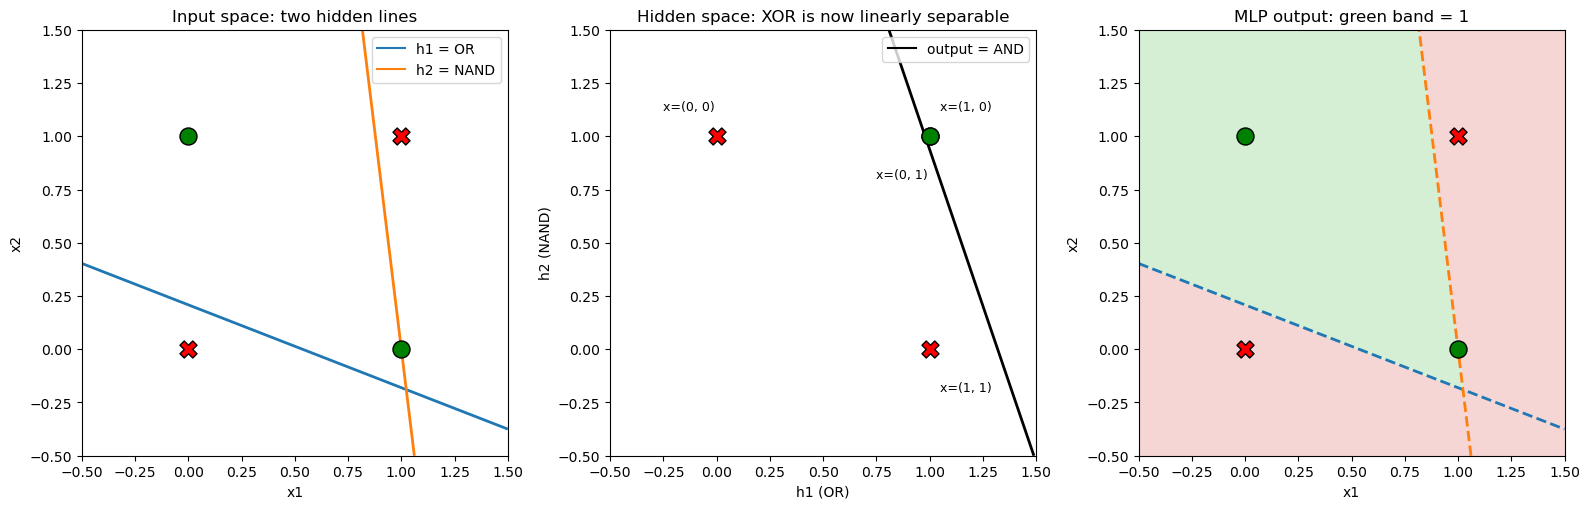

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. the two hidden lines in input space
ax = axes[0]
draw_line(ax, w_h1, color="tab:blue", label="h1 = OR")
draw_line(ax, w_h2, color="tab:orange", label="h2 = NAND")
draw_points(ax, y_xor, "Input space: two hidden lines")
ax.legend(loc="upper right")

# 2. the same 4 inputs in hidden space: now one line separates them
ax = axes[1]
draw_line(ax, w_out, color="k", label="output = AND")
offsets = {(0, 0): (-0.25, 0.12), (0, 1): (-0.25, -0.2), (1, 0): (0.05, 0.12), (1, 1): (0.05, -0.2)}
for x, (h1, h2), t in zip(X, H, y_xor):
    ax.scatter(h1, h2, s=150, c="green" if t else "red", marker="o" if t else "X", edgecolors="k", zorder=3)
    dx, dy = offsets[tuple(x)]
    ax.annotate(f"x={tuple(int(v) for v in x)}", (h1 + dx, h2 + dy), fontsize=9)
ax.set(xlim=(-0.5, 1.5), ylim=(-0.5, 1.5), xlabel="h1 (OR)", ylabel="h2 (NAND)",
       title="Hidden space: XOR is now linearly separable", aspect="equal")
ax.legend(loc="upper right")

# 3. final decision region of the whole network
ax = axes[2]
draw_region(ax, W_hidden, w_out)
draw_line(ax, w_h1, color="tab:blue", style="--")
draw_line(ax, w_h2, color="tab:orange", style="--")
draw_points(ax, y_xor, "MLP output: green band = 1")

plt.tight_layout()
plt.show()

## Experiment 1: learning rate for the output neuron (hidden layer fixed, 50 random starts)

In [11]:
starts = [rng.uniform(-1, 1, 3).round(2) for _ in range(50)]

print(f"{'lr':>8} | {'learned':>7} | {'avg epochs':>10}")
print("-" * 33)
for lr in [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]:
    epochs_needed = [train_quiet(H0, y_xor, s0, lr, epochs=100)[1] for s0 in starts]
    done = [e for e in epochs_needed if e is not None]
    avg = f"{np.mean(done):.1f}" if done else "-"
    print(f"{lr:>8} | {len(done):>3}/50  | {avg:>10}")

      lr | learned | avg epochs
---------------------------------
  0.0001 |   2/50  |        1.0
   0.001 |   5/50  |       34.2
    0.01 |  36/50  |       52.3
     0.1 |  50/50  |       10.8
       1 |  50/50  |        6.7
      10 |  50/50  |        6.4
     100 |  50/50  |        6.4


## Experiment 2: different random starts ➜ different hidden lines, same XOR

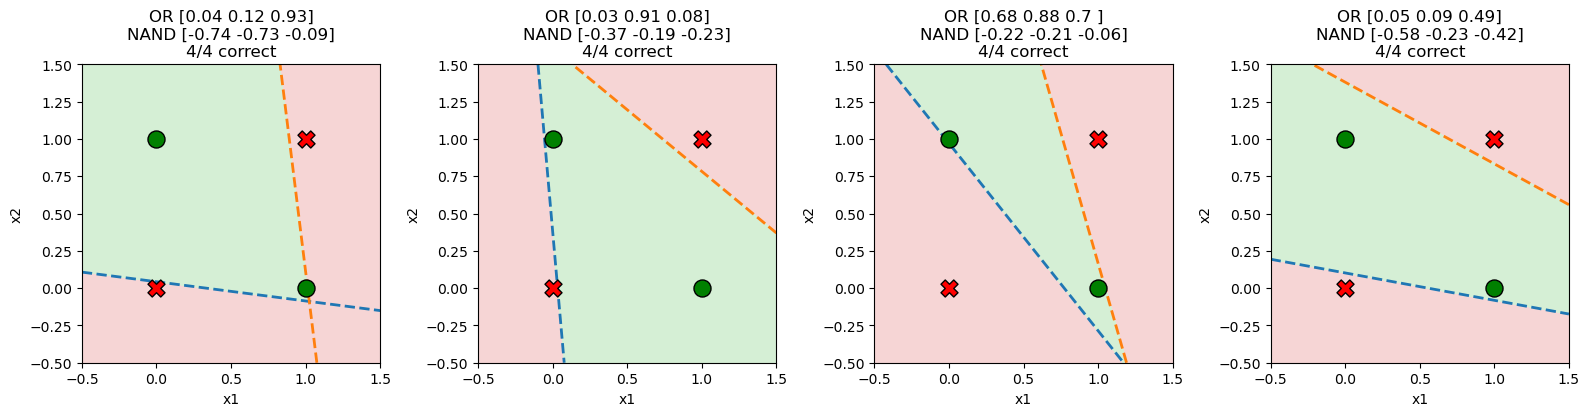

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.3))
for ax in axes:
    a = train_quiet(X0, y_or,   rng.uniform(-1, 1, 3).round(2), 0.1, 100)[0]
    b = train_quiet(X0, y_nand, rng.uniform(-1, 1, 3).round(2), 0.1, 100)[0]
    Hs = add_x0(hidden_layer(X, [a, b]))
    o = train_quiet(Hs, y_xor, rng.uniform(-1, 1, 3).round(2), 0.1, 100)[0]
    y_hat, _ = mlp_forward(X, [a, b], o)
    draw_region(ax, [a, b], o)
    draw_line(ax, a, color="tab:blue", style="--")
    draw_line(ax, b, color="tab:orange", style="--")
    draw_points(ax, y_xor, f"OR {a}\nNAND {b}\n{(y_hat == y_xor).sum()}/4 correct")
plt.tight_layout()
plt.show()

---
# Part 2: no hidden targets — random hidden neurons, train only the output

In Part 1 **we** chose OR and NAND for the hidden layer. Here the hidden weights are **random and never trained**; only the output neuron learns (perceptron rule).

In [13]:
def random_mlp(n_hidden, lr=0.1, epochs=100):
    W_hidden = [rng.uniform(-1, 1, 3).round(2) for _ in range(n_hidden)]
    H0 = add_x0(hidden_layer(X, W_hidden))
    w_out, n, _ = train_quiet(H0, y_xor, rng.uniform(-1, 1, n_hidden + 1).round(2), lr, epochs)
    return W_hidden, w_out, n is not None

tries, ok = 0, False
while not ok:                                  # keep drawing random hidden layers until one works
    W_r, w_r, ok = random_mlp(5)
    tries += 1
print(f"Found a working random hidden layer after {tries} tries\n")
print("Random hidden weights (never trained):")
for j, w in enumerate(W_r, 1):
    print(f"  h{j}: {w}")
print(f"\nOutput weights (trained): {w_r}\nSolved XOR? {ok}\n")
show_mlp(X, y_xor, W_r, w_r)

Found a working random hidden layer after 4 tries

Random hidden weights (never trained):
  h1: [-0.87  0.19 -0.71]
  h2: [ 0.65 -0.38 -0.71]
  h3: [ 0.84 -0.67 -0.43]
  h4: [-0.69 -0.77 -0.96]
  h5: [-0.89 -0.65 -0.89]

Output weights (trained): [ 0.48  0.06 -0.21 -0.36 -0.29  0.45]
Solved XOR? True

x=[0 0] -> hidden [h1=1 h2=0 h3=0 h4=1 h5=1] -> output 0 | target 0 ✓
x=[0 1] -> hidden [h1=1 h2=0 h3=0 h4=0 h5=1] -> output 1 | target 1 ✓
x=[1 0] -> hidden [h1=1 h2=0 h3=0 h4=0 h5=1] -> output 1 | target 1 ✓
x=[1 1] -> hidden [h1=1 h2=0 h3=0 h4=0 h5=0] -> output 0 | target 0 ✓

Accuracy: 4/4


## Experiment 3: how many random hidden neurons are needed? (50 tries each)

hidden neurons | XOR solved
-----------------------------
             1 |      0/50
             2 |      3/50
             3 |      3/50
             5 |     18/50
            10 |     36/50
            20 |     48/50
            50 |     50/50


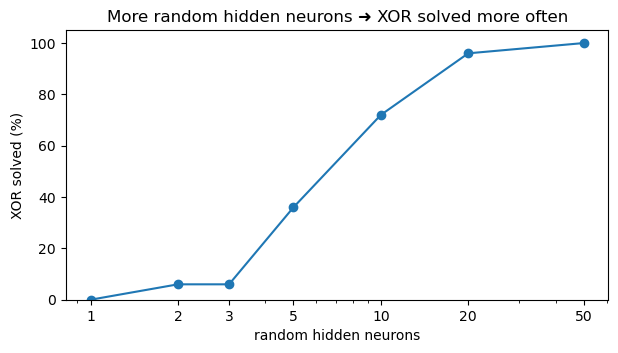

In [14]:
sizes = [1, 2, 3, 5, 10, 20, 50]
rates = []
print(f"{'hidden neurons':>14} | {'XOR solved':>10}")
print("-" * 29)
for n in sizes:
    solved = sum(random_mlp(n)[2] for _ in range(50))
    rates.append(solved / 50 * 100)
    print(f"{n:>14} | {solved:>6}/50")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(sizes, rates, "o-")
ax.set(xscale="log", xticks=sizes, xticklabels=sizes, ylim=(0, 105),
       xlabel="random hidden neurons", ylabel="XOR solved (%)", title="More random hidden neurons ➜ XOR solved more often")
plt.show()

## Graphs: random hidden lines (dashed) and the network output, successes vs failures

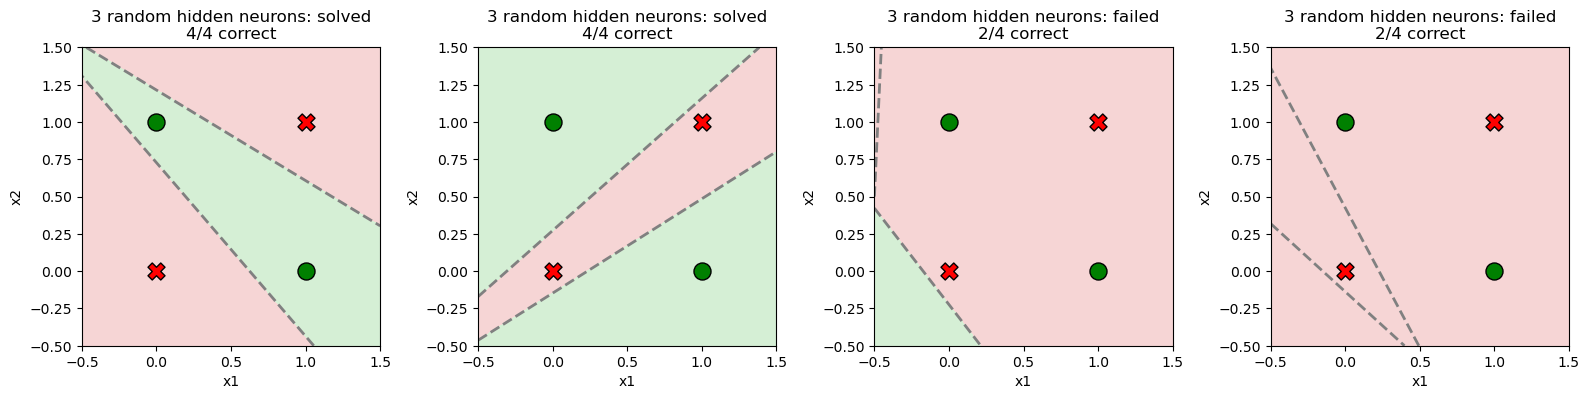

In [15]:
wins, fails = [], []
while len(wins) < 2 or len(fails) < 2:
    W_r, w_r, ok = random_mlp(3)
    (wins if ok else fails).append((W_r, w_r))

fig, axes = plt.subplots(1, 4, figsize=(16, 4.3))
for ax, (W_r, w_r), label in zip(axes, wins[:2] + fails[:2], ["solved", "solved", "failed", "failed"]):
    draw_region(ax, W_r, w_r)
    for w in W_r:
        draw_line(ax, w, color="gray", style="--")
    y_hat, _ = mlp_forward(X, W_r, w_r)
    draw_points(ax, y_xor, f"3 random hidden neurons: {label}\n{(y_hat == y_xor).sum()}/4 correct")
plt.tight_layout()
plt.show()

Random hidden lines only work by luck; the step function gives no signal about **how** to move a hidden line, so the hidden layer can't be trained from the output error. That is what the next notebooks fix.